In [2]:
import torch
import clip

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# Device
device = "mps" if torch.backends.mps.is_available() else "cpu"

# Load CLIP ViT-B/32
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

print("Device:", device)
print("Model: ViT-B/32")

# ViT parameters
print("Input resolution:", model.visual.input_resolution)
print("Patch size:", model.visual.conv1.kernel_size)
print("Patch embedding dimension:", model.visual.conv1.out_channels)
print("Number of Transformer blocks:", len(model.visual.transformer.resblocks))
print("Final CLIP embedding dimension:", model.visual.proj.shape[1])

Matplotlib is building the font cache; this may take a moment.
/Users/prathi/work/CLIP/.clipvenv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Device: mps
Model: ViT-B/32
Input resolution: 224
Patch size: (32, 32)
Patch embedding dimension: 768
Number of Transformer blocks: 12
Final CLIP embedding dimension: 512


Original image size: (626, 939)


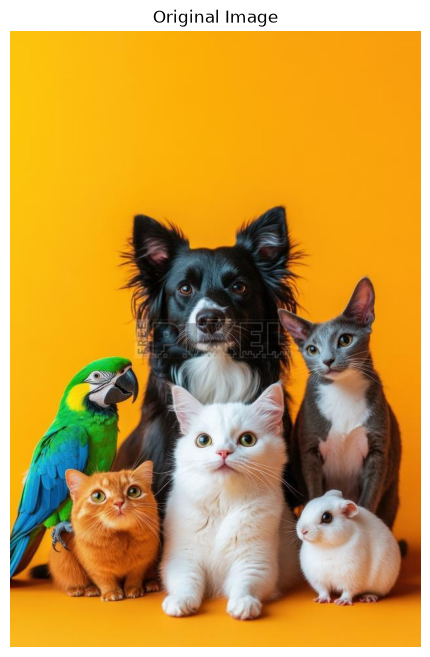

In [ ]:
#2. Visualize the original image
image_path = "/Users/prathi/work/CLIP/learnings/images/National Pet Day Animals.jpg"

image = Image.open(image_path).convert("RGB")

print("Original image size:", image.size)

plt.figure(figsize=(6, 8))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [5]:
#3. Visualize CLIP's preprocessed image

print(preprocess)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x110a1ccc0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


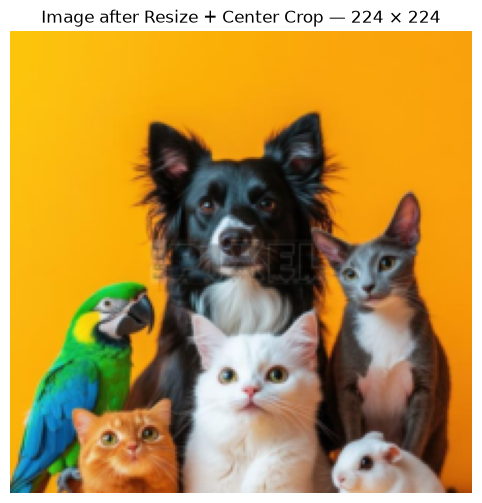

In [6]:
#visual version of the preprocess function
from torchvision import transforms

visual_preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224)
])

image_224 = visual_preprocess(image)

plt.figure(figsize=(6, 6))
plt.imshow(image_224)
plt.title("Image after Resize + Center Crop — 224 × 224")
plt.axis("off")
plt.show()

Tensor shape: torch.Size([1, 3, 224, 224])


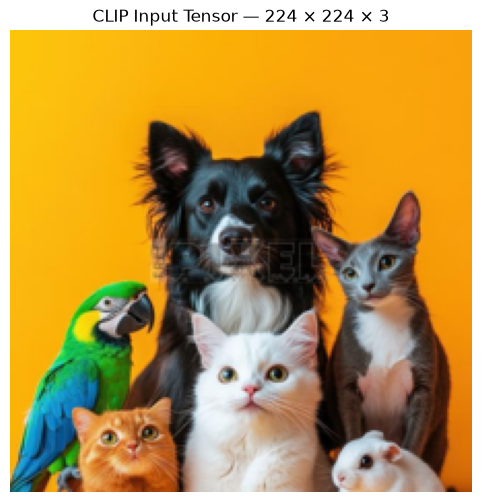

In [8]:
#4. Create the actual tensor

image_tensor = preprocess(image).unsqueeze(0).to(device)

print("Tensor shape:", image_tensor.shape)

# Move image tensor back to CPU
x = image_tensor[0].cpu()

# Undo CLIP normalization for visualization
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

x_visual = x * std + mean
x_visual = x_visual.clamp(0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(x_visual.permute(1, 2, 0))
plt.title("CLIP Input Tensor — 224 × 224 × 3")
plt.axis("off")
plt.show()

In [9]:
#Visualize the 49 patches

image_np = np.array(image_224)

patch_size = 32

patches = []

for row in range(7):
    for col in range(7):
        patch = image_np[
            row * patch_size:(row + 1) * patch_size,
            col * patch_size:(col + 1) * patch_size
        ]
        
        patches.append(patch)

print("Number of patches:", len(patches))
print("Patch shape:", patches[0].shape)

Number of patches: 49
Patch shape: (32, 32, 3)


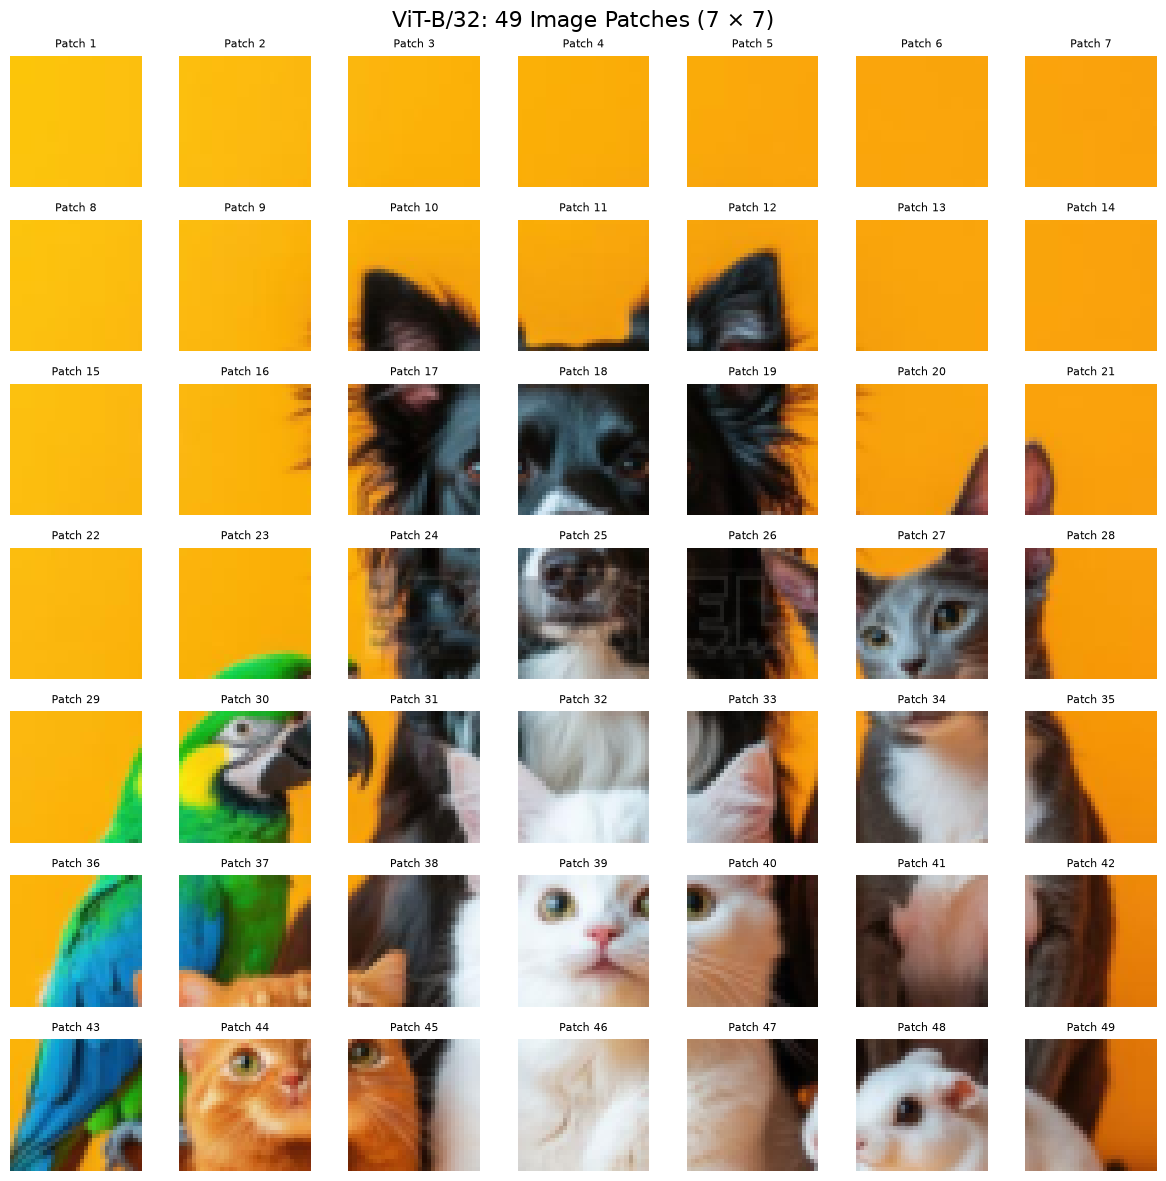

In [10]:
fig, axes = plt.subplots(7, 7, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    ax.imshow(patches[i])
    ax.set_title(f"Patch {i + 1}", fontsize=8)
    ax.axis("off")

plt.suptitle(
    "ViT-B/32: 49 Image Patches (7 × 7)",
    fontsize=16
)

plt.tight_layout()
plt.show()

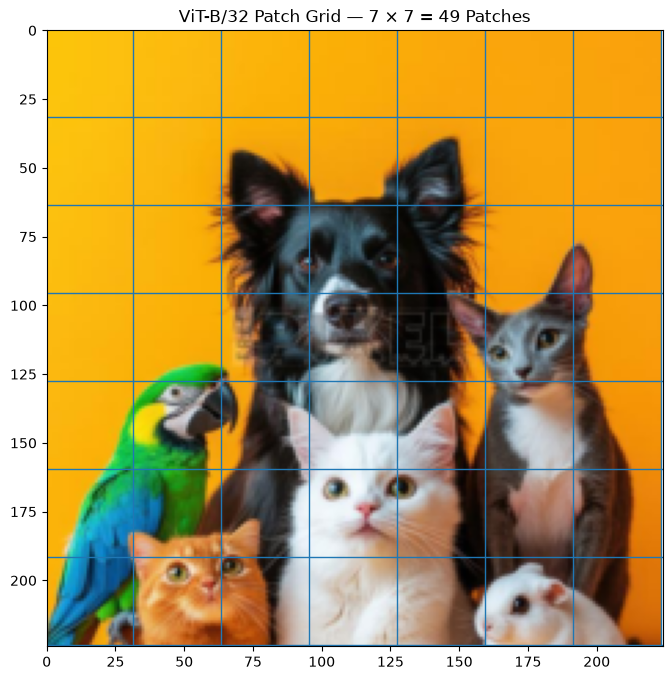

In [11]:
#6. Visualize the patch grid on the original image


fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image_224)

# Draw vertical lines
for x in range(0, 225, 32):
    ax.axvline(x - 0.5, linewidth=1)

# Draw horizontal lines
for y in range(0, 225, 32):
    ax.axhline(y - 0.5, linewidth=1)

ax.set_title("ViT-B/32 Patch Grid — 7 × 7 = 49 Patches")
ax.set_xlim(0, 224)
ax.set_ylim(224, 0)

plt.show()

In [ ]:
#See the Conv2D patch projection
print(model.visual.conv1)

Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)


In [13]:
with torch.no_grad():

    x = image_tensor.to(model.visual.conv1.weight.dtype)

    print("Before patch projection:", x.shape)

    x = model.visual.conv1(x)

    print("After patch projection:", x.shape)

Before patch projection: torch.Size([1, 3, 224, 224])
After patch projection: torch.Size([1, 768, 7, 7])


In [14]:
#8. Visualize the 768 feature maps
feature_maps = x[0].detach().cpu()

print("Feature map tensor:", feature_maps.shape)

Feature map tensor: torch.Size([768, 7, 7])


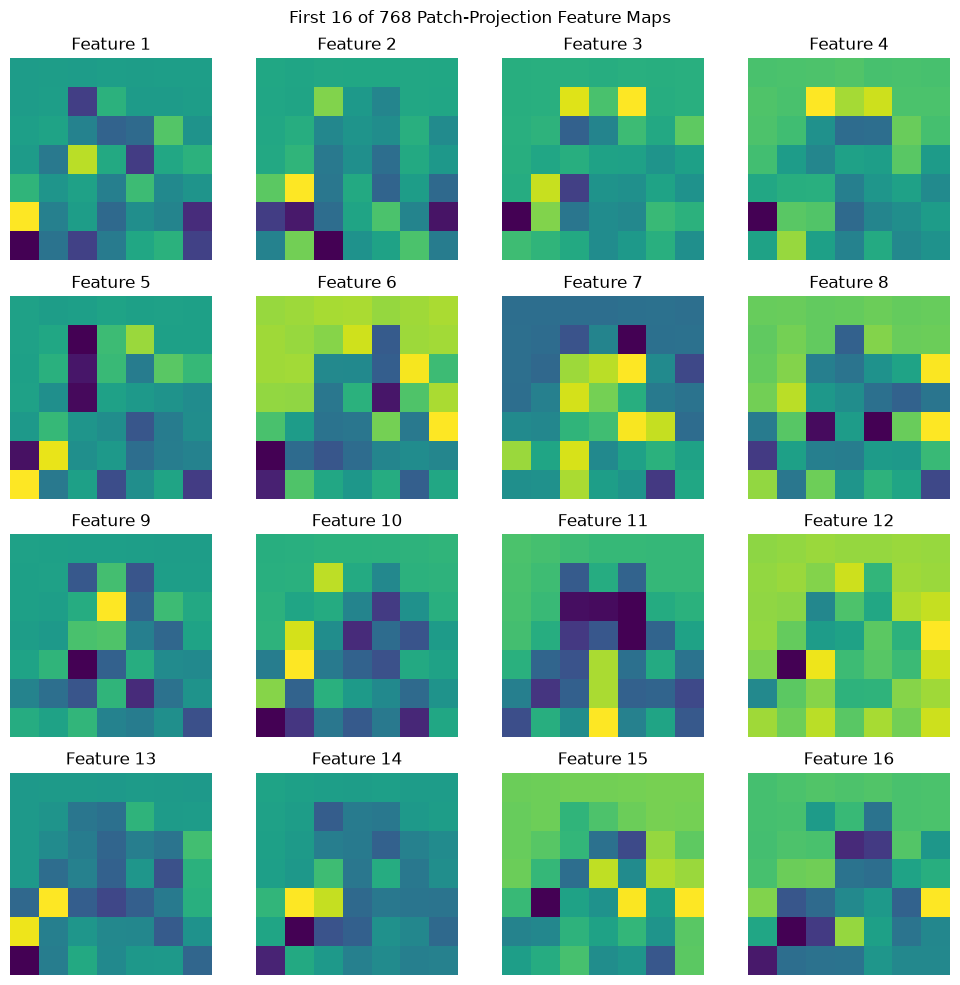

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="viridis")
    ax.set_title(f"Feature {i + 1}")
    ax.axis("off")

plt.suptitle("First 16 of 768 Patch-Projection Feature Maps")
plt.tight_layout()
plt.show()

In [16]:
#9. Convert 7×7×768 → 49×768

patch_embeddings = x.reshape(
    x.shape[0],
    x.shape[1],
    -1
)

patch_embeddings = patch_embeddings.permute(0, 2, 1)

print("Patch embeddings:", patch_embeddings.shape)

Patch embeddings: torch.Size([1, 49, 768])


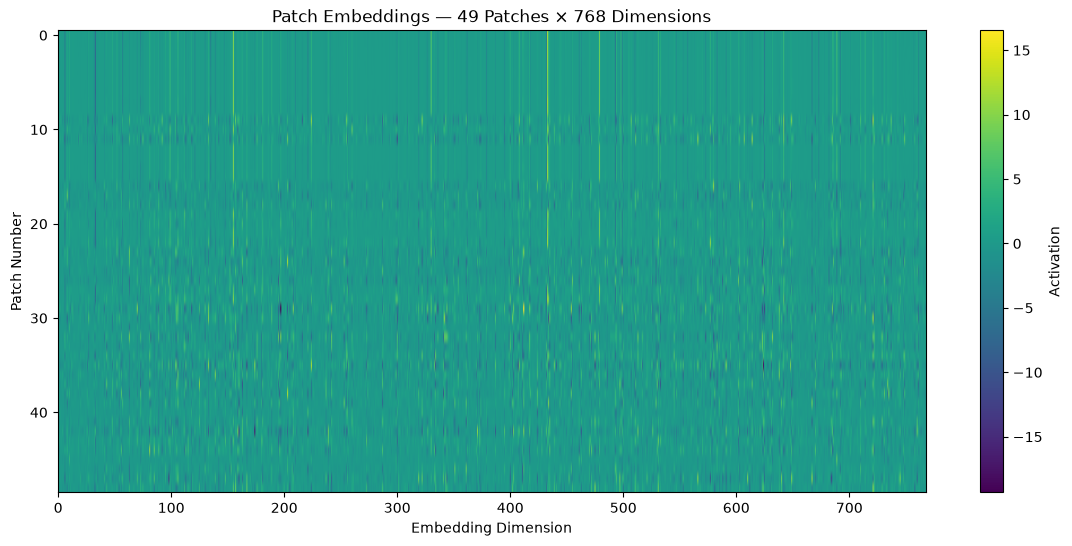

In [18]:
embedding_matrix = patch_embeddings[0].detach().cpu().numpy()

plt.figure(figsize=(14, 6))

plt.imshow(
    embedding_matrix,
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Patch Number")
plt.title("Patch Embeddings — 49 Patches × 768 Dimensions")

plt.colorbar(label="Activation")

plt.show()

In [20]:
#10. Add the CLS token
visual = model.visual

class_embedding = visual.class_embedding

cls_token = class_embedding.to(patch_embeddings.dtype)

cls_token = cls_token + torch.zeros(
    patch_embeddings.shape[0],
    1,
    patch_embeddings.shape[-1],
    device=device,
    dtype=patch_embeddings.dtype
)

print("CLS token:", cls_token.shape)

tokens = torch.cat(
    [cls_token, patch_embeddings],
    dim=1
)

print("Tokens including CLS:", tokens.shape)


CLS token: torch.Size([1, 1, 768])
Tokens including CLS: torch.Size([1, 50, 768])


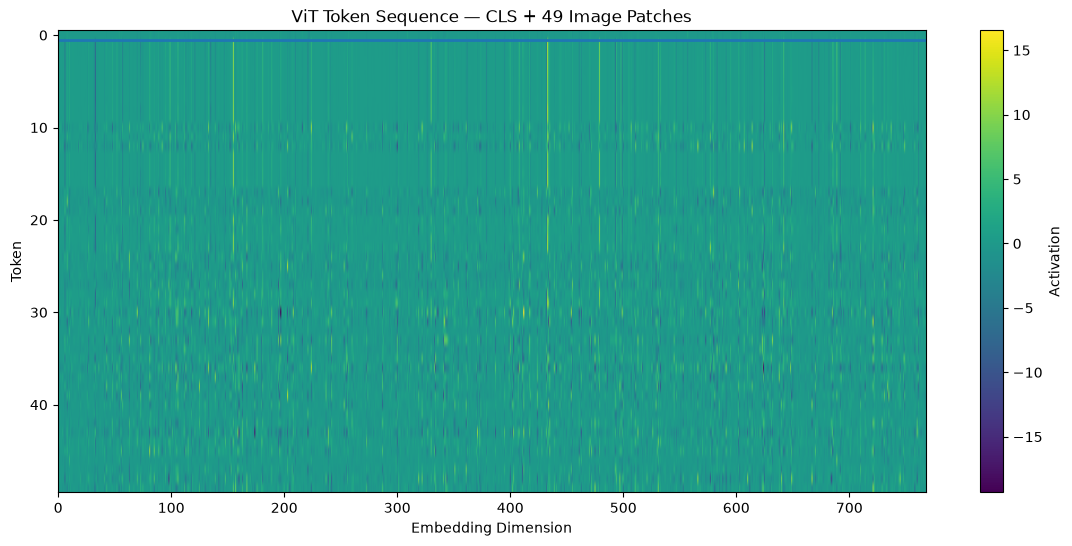

In [21]:
#11. Visualize CLS + 49 patch tokens

token_matrix = tokens[0].detach().cpu().numpy()

plt.figure(figsize=(14, 6))

plt.imshow(
    token_matrix,
    aspect="auto"
)

plt.axhline(
    y=0.5,
    linewidth=2
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Token")
plt.title("ViT Token Sequence — CLS + 49 Image Patches")

plt.colorbar(label="Activation")

plt.show()

Positional embedding:
torch.Size([50, 768])


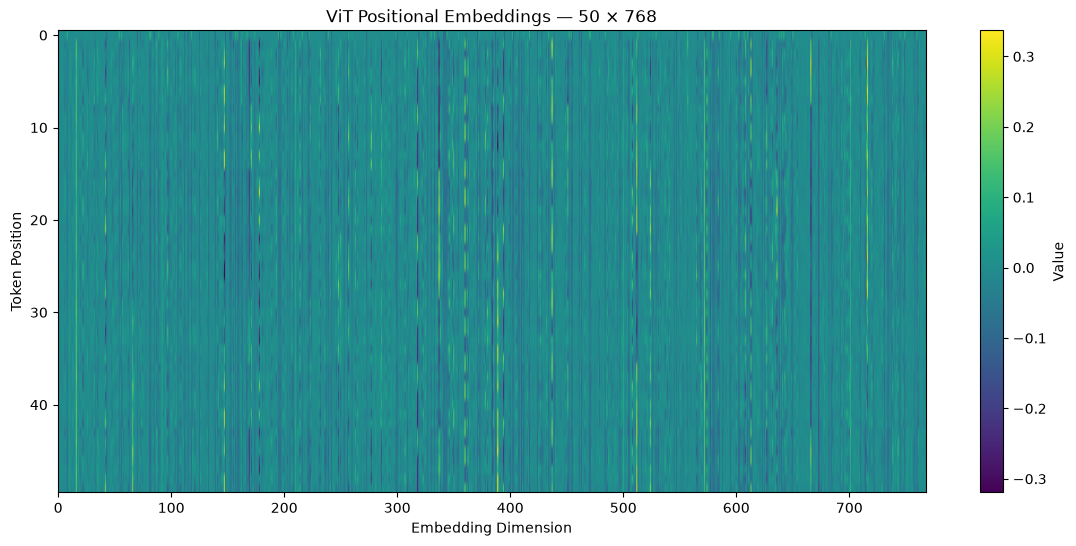

In [23]:
#12. Visualize positional embeddings
positional_embedding = visual.positional_embedding

print("Positional embedding:")
print(positional_embedding.shape)

plt.figure(figsize=(14, 6))

plt.imshow(
    positional_embedding.detach().cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.title("ViT Positional Embeddings — 50 × 768")

plt.colorbar(label="Value")

plt.show()

Transformer input: torch.Size([1, 50, 768])


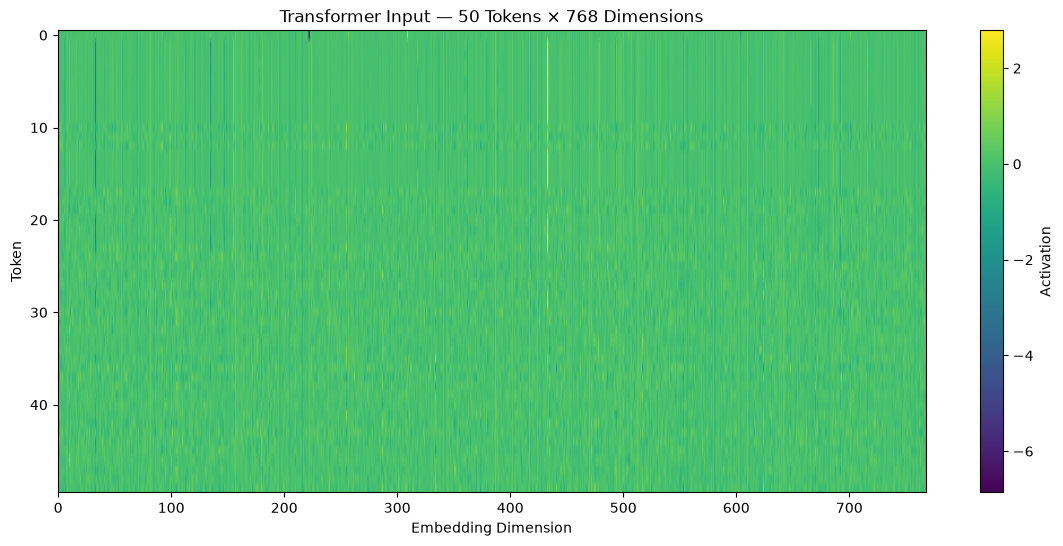

In [24]:
#13. Visualize the Transformer input
tokens_with_position = (
    tokens +
    visual.positional_embedding.to(tokens.dtype)
)

tokens_normalized = visual.ln_pre(tokens_with_position)

print("Transformer input:", tokens_normalized.shape)

plt.figure(figsize=(14, 6))

plt.imshow(
    tokens_normalized[0].detach().cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Token")
plt.title("Transformer Input — 50 Tokens × 768 Dimensions")

plt.colorbar(label="Activation")

plt.show()

In [25]:
#14. Pass through the Transformer
transformer_input = tokens_normalized.permute(1, 0, 2)

print("Before Transformer:", transformer_input.shape)

with torch.no_grad():
    transformer_output = visual.transformer(transformer_input)

print("After Transformer:", transformer_output.shape)

Before Transformer: torch.Size([50, 1, 768])
After Transformer: torch.Size([50, 1, 768])


torch.Size([1, 50, 768])


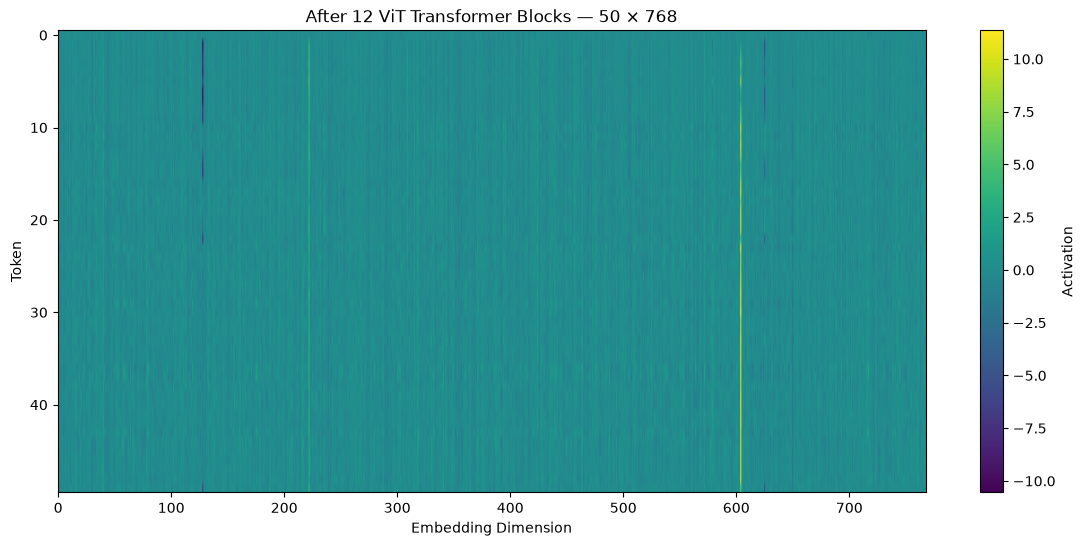

In [26]:
#15. Visualize Transformer output
transformer_output = transformer_output.permute(1, 0, 2)

print(transformer_output.shape)
plt.figure(figsize=(14, 6))

plt.imshow(
    transformer_output[0].detach().cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Token")
plt.title("After 12 ViT Transformer Blocks — 50 × 768")

plt.colorbar(label="Activation")

plt.show()

CLS representation: torch.Size([1, 768])


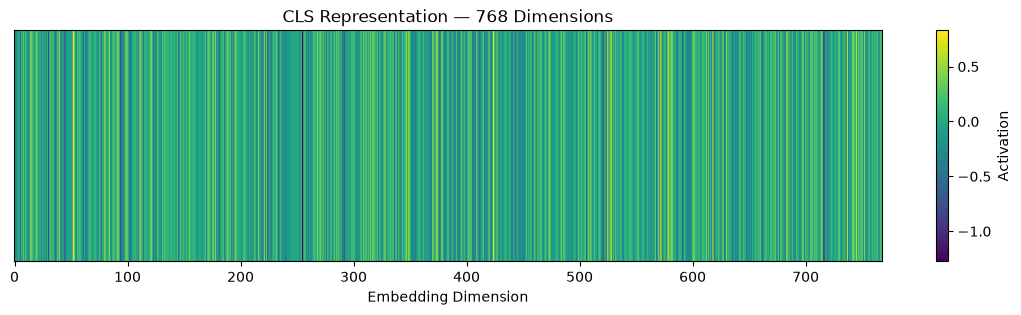

In [27]:
#16. Extract the CLS representation
cls_output = transformer_output[:, 0, :]

print("CLS representation:", cls_output.shape)

plt.figure(figsize=(14, 3))

plt.imshow(
    cls_output.detach().cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.yticks([])
plt.title("CLS Representation — 768 Dimensions")

plt.colorbar(label="Activation")

plt.show()

Final CLIP embedding: torch.Size([1, 512])


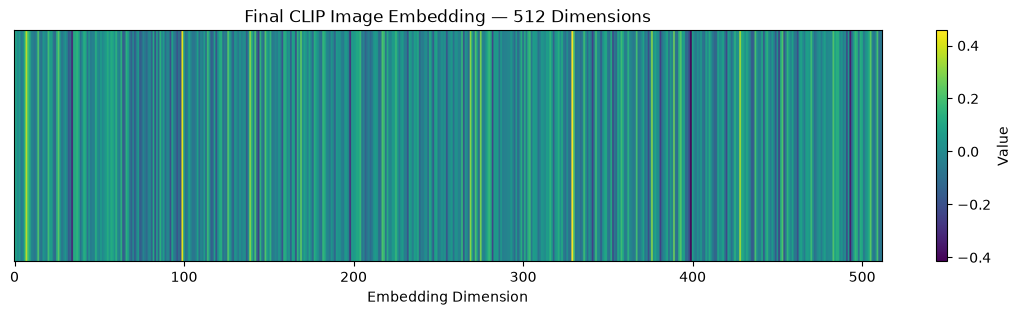

In [28]:
image_embedding = cls_output @ visual.proj

print("Final CLIP embedding:", image_embedding.shape)
plt.figure(figsize=(14, 3))

plt.imshow(
    image_embedding.detach().cpu().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.yticks([])
plt.title("Final CLIP Image Embedding — 512 Dimensions")

plt.colorbar(label="Value")

plt.show()

In [29]:
#18. Normalize the final 

image_embedding_normalized = (
    image_embedding /
    image_embedding.norm(dim=-1, keepdim=True)
)

print(
    "Embedding norm:",
    image_embedding_normalized.norm(dim=-1)
)

Embedding norm: tensor([1.], device='mps:0', dtype=torch.float16, grad_fn=<NormBackward1>)
